# Projekt: Optimaler Standort für eine Elektro-Motorrad Messe in Zürich

### Ersteller/in:
<li> Fabian Pfister (T WB-T-CAS-INFE-2-24-17) </li>
<li> Perrine Rotzetter (T WB-T-CAS-INFE-2-24-17) </li>
<li> Stefan Schegg (T WB-T-CAS-INFE-2-24-17) </li>

Anmerkung: Damit das Skript läuft müssen die vorangegangenen Skripts kompiliert worden sein, ein Ordner "data" und ein Ordner "pictures" im gleichen Ordner wie das Skript existieren. \
Ordner "data": Hier ist die ursprüngliche Datengrundlage Gemeindedaten und Geodaten sowie Resultate vorheriger Skript abgespeichert. \
Ordner "pictures": Plots dieses Skripts werden in diesem Ordner abgespeichert.

## Importiere Bibliotheken

### Installiere Bibliotheken

In [2]:
# Bei Bedarf Dekommentieren.
# !pip install pandas geopandas

#Sicherstellen das spezifische Version von folium installiert wird sodass "Chloropeth" zur Verfügung steht.
# !pip install folium==0.16.0

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests
import folium
from datetime import datetime, timedelta
import statistics
import numpy as np
import json
import geopandas

## Importiere notwendige Daten

In [4]:
# Definiere Filepath
daten_path = "./data/df_gesamt.csv"
df_gesamt = pd.read_csv(daten_path)

In [5]:
# Ranking Daten
df_ranking_path = "./data/df_ranking.csv"
df_ranking = pd.read_csv(df_ranking_path)

# Daten Vorbereiten

In [6]:
# Gleiche Schreibweise BFS_NR den Energy-Reporter Daten an.
df_gesamt.rename(columns={'BFS_NR': 'bfs_nr'}, inplace=True)

# Gebietname aus einem Dataframe entfernen
df_ranking = df_ranking.drop('municipality', axis=1)

# merge ranking mit Gemeindedaten
df_gesamt_ranking = pd.merge(df_gesamt, df_ranking[['Ranking Gesamt [Punkte]', 'Rangliste', 'bfs_nr']], on=["bfs_nr"])

In [7]:
# sortiere dataframe
df_gesamt_ranking = df_gesamt_ranking.sort_values(by = "Ranking Gesamt [Punkte]", ascending = False)

In [8]:
# Spaltennamen umbennen
df_gesamt_ranking.rename(columns={"Bevölkerung: Anteil 20-39-Jährige [%] ": "Anteil 20-39 Jährige [%]", "Bevölkerung: Anteil 40-64-Jährige [%] ": "Anteil 40-64 Jährige [%]","Bestand Elektromotor [%] ": "Anteil Elektormotoren [%]","electric_cars_per_charging_spot": "Elektroautos pro Ladeplatz [Anz.]", "electric_car_charging_spot_count": "Elektroauto-Ladeplätze [Anz.]", "MIV-Anteil (Modal Split) [%] ": "Weg zur nächsten öV Haltestelle [m]"}, inplace=True)
df_ranking.rename(columns={"Bevölkerung: Anteil 20-39-Jährige [%] ": "Anteil 20-39 Jährige [%]", "Bevölkerung: Anteil 40-64-Jährige [%] ": "Anteil 40-64 Jährige [%]","Bestand Elektromotor [%] ": "Anteil Elektormotoren [%]","electric_cars_per_charging_spot": "Elektroautos pro Ladeplatz [Anz.]", "electric_car_charging_spot_count": "Elektroauto-Ladeplätze [Anz.]", "MIV-Anteil (Modal Split) [%] ": "Weg zur nächsten öV Haltestelle [m]"}, inplace=True)

In [9]:
df_gesamt_ranking.head()

,bfs_nr,JAHR,Anteil 20-39 Jährige [%],Anteil 40-64 Jährige [%],Motorräder [Anz.],Motorräder pro 1000 Einwohner [Anz.],Anteil Elektormotoren [%],Bevölkerung [Pers.],Ø steuerbares Einkommen natürliche Pers. [Fr.],Ø steuerbares Vermögen natürliche Pers. [Fr.],...,Motorrad-Neuzulassungen [Anz.],Motorrad-Neuzulasssungen pro 1000 Einw. [Anz.],Neuzulassungen Elektromotor [%],Weg zur nächsten Haltestelle [m],municipality,canton,Elektroauto-Ladeplätze [Anz.],Elektroautos pro Ladeplatz [Anz.],Ranking Gesamt [Punkte],Rangliste
117,195,2023,19.0,39.8,1234,114.9,5.8,10901,88661,922000000,...,83,7.7,32.3,232.0,Maur,ZH,10,43.8,72.98,1.0
107,176,2023,22.3,38.2,630,110.2,5.0,5860,67817,407000000,...,29,5.1,30.2,166.0,Lindau,ZH,28,7.9,72.65,2.0
121,199,2023,24.8,36.8,1556,80.1,3.6,19717,66931,343000000,...,89,4.6,23.1,212.0,Volketswil,ZH,41,11.8,70.89,3.0
9,10,2023,24.4,34.7,513,88.8,4.7,5842,65390,355000000,...,41,7.1,29.7,211.0,Obfelden,ZH,20,9.0,68.92,4.0
32,51,2023,21.9,35.8,331,78.8,6.1,4315,62913,382000000,...,22,5.2,24.2,222.0,Bachenbülach,ZH,17,10.1,67.03,5.0


## Plots
### Heatmap
Erstelle Karte mit Daten

In [10]:
# baiert auf: https://python-visualization.github.io/folium/latest/user_guide/geojson/geojson_popup_and_tooltip.html

# Einlesen und Filtern Quelle 1:
# Aufbereitete Daten aus dem vorigen Notebook wieder einlesen

df_gesamt_path = "./data/df_gesamt.csv"
df_AnzMot = pd.read_csv(df_gesamt_path)

In [11]:
# Einlesen Quelle 2:
# Geojson mit den Geodaten der Gemeinden vom Kanton Zürich im Jahre 2019 (keine aktuelleren Daten gefunden, da wohl keine Änderungen mehr erfolgt sind seither).
# Problem an der Stelle war erstmal noch rauszufinden, dass es verschiedene Schreibweisen gibt wie Koordinaten abgespeichert werden. Jedenfalls konnte nur das Format epsg4326 weiterverarbeit werden. 
# Dieses enthält das für uns übliche Format 45 Grad Breite und 8 Grad Länge.


# File öffnen, in python als json speichern unter geo_data.
geo_data = json.load(open('./data/GEN_A4_GEMEINDEN_2019_epsg4326.json'))

for i in range(1,len(geo_data['features'])):
    to_check = geo_data['features'][i]['properties']['NAME']
    if to_check.endswith("(ZH)"):
        geo_data['features'][i]['properties']["NAME"]=to_check.rstrip("ZH() ")
        #print(geo_data['features'][i]['properties']['NAME'])


In [12]:
# Die beiden Quellen zusammenführen

# Zuerst lesen wir das modifizierte geo_data json Objekt aus. Und zwar nur die Features und speichern das als GeoDataFrame Ojekt namens gemeinden.
gemeinden = geopandas.GeoDataFrame.from_features(geo_data, crs="EPSG:4326")


# Nun mergen wir die erste Quelle namens df_AnzMot mit dem aufbereiteten GeoDataFrame. Und zwar anhand der Splate NAME in den Geo Daten (Quelle 2) und der Municipality aus Quelle 1.
# Das Resultat wird als gemeindemerge abgespeichert.
gemeindemerge = gemeinden.merge(df_AnzMot, how="left", left_on="NAME", right_on="municipality")


# Jetzt mergen wir noch das Ranking der Gemeinden rein.
daten_path = "./data/df_ranking.csv"
ranking = pd.read_csv(daten_path)

gemeinderanking = gemeindemerge.merge(ranking,left_on="municipality",right_on="municipality")

In [13]:
# Karte erstellen

# Nachdem die Daten jetzt aufbereitet sind, wird mit Folium mal eine Map kreiert, zu welcher im Anschluss diverse Elemente (Choropleth map, tooltips und features wie CircleMarker)  hinzugefügt werden. 
zuerich_map = folium.Map(location=[47.45,8.61], zoom_start=10.4)


# Als erstes wird eine Choropleth Karte erstellt, basierend auf den gemergten Geodaten der Gemeinden und der Anzahl Motorräder pro Gemeinde. Mit add_to wird dieser Choropleth der vorgägnig erstellten zuerich_map hinzugefügt.
# Für die Skalierung der des Choropleth ist der Höchstwert der Daten interessant (also in diesem Falle was ist die höchste Zahl an zugelassenen Motorrädern in einer Gemeinde) Deshalb wird dieser vorgänig noch ausgelesen und abgespeichert.speichern uns den mal ab.
verlierer = gemeinderanking['Rangliste'].max()


# Und jetzt wie erwähnt, der Choropleth, der am Ende der zuerich_map hinzugefügt wird. Da wir die Daten vorgänig zusammengefügt haben ist die Datenquelle und die Geo Daten Quelle identisch.
# Die treshold_scale definiert die Schwellwerte ab wann eine Gemeinde aufgrund der Anzahl Motorräder farblich anders dargestellt wird. Das macht bei massiven Ausreissern wie Zürich und Winterthur in dem Beispiel so nur wenig Sinn.
# Daher die Kategorien bis 1% von max, zwischen 1 und 2 % von max, zwischen 2 und 20% von max sowie alles darüber bis zu max.

folium.Choropleth(
    geo_data=gemeinderanking,
    data=gemeinderanking,
    columns=['municipality', 'Rangliste'],
    key_on='feature.properties.NAME',
    fill_color='YlGn', 
    fill_opacity=0.7, 
    line_opacity=0.5,
    nan_fill_color="white",
    nan_fill_opacity=1.0,
    threshold_scale = [verlierer-(verlierer-1),verlierer*0.1,verlierer*0.50,verlierer*0.75,verlierer*.95,verlierer],
).add_to(zuerich_map) 


In [14]:
# Jetzt folgt der Tooltip, damit beim hoovern über die Karte die Daten der jeweiligen Gemeinde angezeigt werden.
# Der Code hierfür stammt im Wesentlichen von https://gis.stackexchange.com/questions/392531/modify-geojson-tooltip-format-when-using-folium-to-produce-a-map und wurde lediglich auf unsere Datenquellen angepasst.
# Grundsätzlich wird durch die gemergten Daten iteriert, die jeweilige Zeile als Feature als folium GeoJson Feature abgespeichert um zu wissen wo sich die Gemeinde auf der Karte befindet und was für Daten diese enthält.
# Die besagten Daten werden dann als Tooltip angezeigt, sobald sich die Maus auf der Karte auf den zugehörigen GeoDaten befindet. Auch das Konstrukt wird zu unserer zuerich_map hinzugefügt.

style_function = lambda x: {'fillColor': '#ffffff', 
                            'color':'#000000', 
                            'fillOpacity': 0.1, 
                            'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000', 
                                'color':'#000000', 
                                'fillOpacity': 0.50, 
                                'weight': 0.1}

for i in range(len(gemeinderanking)):
    row = gemeinderanking.loc[[i]]
    feature = folium.features.GeoJson(
    row,
    style_function=style_function,
    control=False,
    highlight_function=highlight_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=[
            'NAME',
            'Bevölkerung [Pers.] ',
            'Bevölkerung: Anteil 20-39-Jährige [%] _x',
            'Bevölkerung: Anteil 40-64-Jährige [%] _x',
            'Ø steuerbares Einkommen natürliche Pers. [Fr.] _x',
            'Motorräder pro 1000 Einwohner [Anz.] _x',
            'Motorrad-Neuzulasssungen pro 1000 Einw. [Anz.] _x',
            'Bestand Elektromotor [%] _x',
            'Neuzulassungen  Elektromotor [%] _x',
            'MIV-Anteil (Modal Split) [%] ',
            'Weg zur nächsten Haltestelle [m] _x',
            'electric_cars_per_charging_spot_y',
            'electric_car_charging_spot_count_y',
            'Erschliessung durch S-Bahn+Bus [% der Einw.] _y',
            'Rangliste',
            ],
        aliases=[
            "Gemeinde: ",
            "Anzahl Personen: ",
            "Anteil 20-39 Jährige [%]",
            "Anteil 40-64 Jährige [%]",
            "Ø steuerbares Einkommen natürliche Pers. [Fr.]",
            "Motorräder pro 1000 Einwohner [Anz.]",
            "Motorrad-Neuzulasssungen pro 1000 Einw. [Anz.]",
            "Anteil Elektormotoren [%]",
            "Neuzulassungen  Elektromotor [%]",
            "Anteil motorisierter Individualverkehr [%]",
            "Weg zur nächsten öV Haltestelle [m]",
            'Elektroautos pro Ladeplatz [Anz.]',
            'Elektroauto-Ladeplätze [Anz.]',
            'Erschliessung durch S-Bahn+Bus [% der Einw.]',
            "Rang",
            ],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
        )
        ).add_to(zuerich_map)

In [15]:
# Schliesslich zeigen wir die Karte an.
display(zuerich_map)

### Top 10 Ranking 2023
Histogramm

In [16]:
# get the top 10 entries
df_gesamt_ranking_top10 = df_gesamt_ranking[0:10]
df_gesamt_ranking_top10

,bfs_nr,JAHR,Anteil 20-39 Jährige [%],Anteil 40-64 Jährige [%],Motorräder [Anz.],Motorräder pro 1000 Einwohner [Anz.],Anteil Elektormotoren [%],Bevölkerung [Pers.],Ø steuerbares Einkommen natürliche Pers. [Fr.],Ø steuerbares Vermögen natürliche Pers. [Fr.],...,Motorrad-Neuzulassungen [Anz.],Motorrad-Neuzulasssungen pro 1000 Einw. [Anz.],Neuzulassungen Elektromotor [%],Weg zur nächsten Haltestelle [m],municipality,canton,Elektroauto-Ladeplätze [Anz.],Elektroautos pro Ladeplatz [Anz.],Ranking Gesamt [Punkte],Rangliste
117,195,2023,19.0,39.8,1234,114.9,5.8,10901,88661,922000000,...,83,7.7,32.3,232.0,Maur,ZH,10,43.8,72.98,1.0
107,176,2023,22.3,38.2,630,110.2,5.0,5860,67817,407000000,...,29,5.1,30.2,166.0,Lindau,ZH,28,7.9,72.65,2.0
121,199,2023,24.8,36.8,1556,80.1,3.6,19717,66931,343000000,...,89,4.6,23.1,212.0,Volketswil,ZH,41,11.8,70.89,3.0
9,10,2023,24.4,34.7,513,88.8,4.7,5842,65390,355000000,...,41,7.1,29.7,211.0,Obfelden,ZH,20,9.0,68.92,4.0
32,51,2023,21.9,35.8,331,78.8,6.1,4315,62913,382000000,...,22,5.2,24.2,222.0,Bachenbülach,ZH,17,10.1,67.03,5.0
108,177,2023,23.8,35.2,924,74.7,3.9,12484,65839,408000000,...,45,3.6,28.1,227.0,Pfäffikon,ZH,20,15.0,66.82,6.0
1,2,2023,27.2,33.2,849,67.8,3.7,12812,60095,314000000,...,32,2.6,26.1,263.0,Affoltern am Albis,ZH,18,15.9,66.64,7.0
120,198,2023,25.8,35.8,2426,67.9,3.9,36279,66359,387000000,...,128,3.6,26.3,170.0,Uster,ZH,39,19.3,66.49,8.0
132,223,2023,19.9,38.3,630,109.5,4.2,5758,74646,508000000,...,22,3.8,28.8,219.0,Neftenbach,ZH,7,24.7,66.19,9.0
82,117,2023,24.5,35.2,1061,91.8,3.3,11824,60378,373000000,...,41,3.5,22.2,267.0,Hinwil,ZH,21,15.0,65.20,10.0


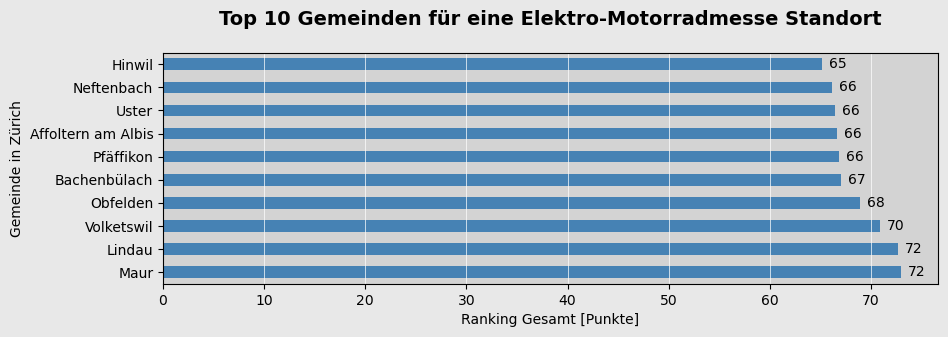

In [17]:
# Hintergrundfarbe setzen
fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor('#E8E8E8')
ax.set_facecolor('#D3D3D3')

#Histogramm erstellen
df_gesamt_ranking_top10.plot(kind='barh', x='municipality', y='Ranking Gesamt [Punkte]', ax=ax, figsize=(10, 3), color='steelblue', legend = False)

plt.xlabel('Ranking Gesamt [Punkte]')
plt.ylabel('Gemeinde in Zürich')

# Gitternetzlinien hinzufügen
ax.grid(True, axis = 'x', which='both', linestyle='-', linewidth=0.5, color = 'white')

# Titel des Diagramms
plt.title('Top 10 Gemeinden für eine Elektro-Motorradmesse Standort', fontsize=14, fontweight='bold', pad=20)


# Wertelabels annotieren
for index, value in enumerate(df_gesamt_ranking_top10['Ranking Gesamt [Punkte]']):
    label = format(int(value), ',')  # Formatieren des Werts mit Kommas

    # Text am Ende des Balkens platzieren (Anpassung der Position für bessere Lesbarkeit)
    plt.annotate(label, xy=(value, index), xytext=(5, 0),
                 textcoords='offset points', ha='left', va='center', color='black')

# Plot als .jpg speichern
plt.savefig("./pictures/Histogramm_Top10.jpg", format='jpg')

plt.show()


### Analyse geeigneteste Gemeinde

In [18]:
# Name der geeignetsten Gemeinde extrahieren
top_gemeinde = df_gesamt_ranking[df_gesamt_ranking["Rangliste"] == 1]
top_gemeinde = top_gemeinde['municipality'].iloc[0]

In [19]:
# Geeignetste Gemeinde extrahieren
df_geeignetste_gemeinde = df_ranking[df_ranking["Rangliste"] == 1]

# Nicht notwendige Spalten löschen
df_geeignetste_gemeinde = df_geeignetste_gemeinde.drop(['bfs_nr', 'Rangliste'], axis=1)

# leerer Vektor für Prozente 
v_kreisdiagramm = []
# Gesamtepunktzahl (= 100%)
gesamt_punktzahl = df_geeignetste_gemeinde['Ranking Gesamt [Punkte]'].iloc[0]
# nicht notwendige Spalte löschen
df_geeignetste_gemeinde = df_geeignetste_gemeinde.drop(['Ranking Gesamt [Punkte]'], axis=1)

In [20]:
# Prozentsätze pro Kategorie berechnen
prozent = 0
for i in range(0, len(df_geeignetste_gemeinde.columns)):
    prozent = 100/gesamt_punktzahl * df_geeignetste_gemeinde.iloc[0, i]
    v_kreisdiagramm.append(prozent)    

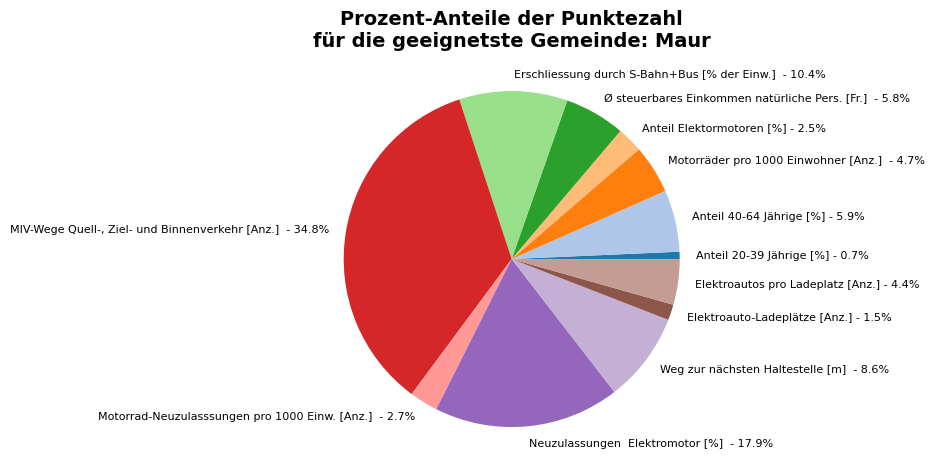

In [21]:
# Kreisdiagramm erstellen
fig, ax = plt.subplots()

# Farben für die Labels
colors = plt.cm.tab20.colors

# Kreisdiagramm mit Labels, Prozentangaben und Linien
wedges, texts = ax.pie(
    v_kreisdiagramm, 
    labels=[f'{label} - {value:.1f}%' for label, value in zip(df_geeignetste_gemeinde.columns, v_kreisdiagramm)],
    colors = colors,
    textprops=dict(color="black", fontsize=8),
)

# Titel des Diagramms
plt.title(f'Prozent-Anteile der Punktezahl\nfür die geeignetste Gemeinde: {top_gemeinde}', fontsize=14, fontweight='bold', pad=20)

# Gleichmäßiges Seitenverhältnis gewährleisten
plt.axis('equal')

# Plot als .jpg speichern
plt.savefig("./pictures/Kreisdiagramm_top_gemeinde.jpg", format='jpg')

# Diagramm anzeigen
plt.show()

### Top 3 Gemeinden pro Kriterium

In [22]:
df_ranking_list = pd.DataFrame()

# Iteriere durch alle Spalten mit Attributen. Erstelle individuelle Rangliste für jedes Attribut.
for i in range(0, len(df_ranking.columns)-3):
    # Kolonnen Name
    col_name = df_ranking.columns[i]
    # Füge eine Rangliste anhand des erstellten Rankings hinzu.
    df_ranking[col_name + "_rank"] = df_ranking[col_name].rank(ascending=False, method='dense')

In [23]:
# Erstelle ein neues DataFrame mit den Spalten, die '_rank' enthalten
rank_columns = [col for col in df_ranking.columns if '_rank' in col]
df_ranking_only = df_ranking[rank_columns].copy()
df_ranking_only["Rangliste"] = df_ranking["Rangliste"] 

# Entferne '_rank' aus den Spaltennamen
df_ranking_only.columns = [col.replace('_rank', '') for col in df_ranking_only.columns]

In [24]:
df_ranking_only

,Anteil 20-39 Jährige [%],Anteil 40-64 Jährige [%],Motorräder pro 1000 Einwohner [Anz.],Anteil Elektormotoren [%],Ø steuerbares Einkommen natürliche Pers. [Fr.],Erschliessung durch S-Bahn+Bus [% der Einw.],"MIV-Wege Quell-, Ziel- und Binnenverkehr [Anz.]",Motorrad-Neuzulasssungen pro 1000 Einw. [Anz.],Neuzulassungen Elektromotor [%],Weg zur nächsten Haltestelle [m],Elektroauto-Ladeplätze [Anz.],Elektroautos pro Ladeplatz [Anz.],Rangliste
0,82.0,3.0,15.0,2.0,20.0,1.0,120.0,64.0,11.0,64.0,34.0,99.0,70.0
1,14.0,72.0,131.0,28.0,129.0,35.0,17.0,60.0,57.0,33.0,18.0,18.0,7.0
2,56.0,39.0,73.0,16.0,41.0,37.0,89.0,38.0,73.0,73.0,31.0,74.0,121.0
3,80.0,19.0,49.0,15.0,56.0,1.0,109.0,37.0,45.0,48.0,30.0,52.0,60.0
4,45.0,29.0,86.0,16.0,29.0,89.0,100.0,27.0,47.0,36.0,34.0,99.0,124.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,35.0,56.0,91.0,31.0,120.0,39.0,74.0,17.0,73.0,14.0,34.0,99.0,106.0
156,36.0,47.0,112.0,16.0,33.0,28.0,14.0,44.0,51.0,98.0,29.0,93.0,32.0
157,16.0,69.0,135.0,33.0,135.0,75.0,18.0,53.0,73.0,81.0,20.0,38.0,80.0
158,44.0,34.0,26.0,38.0,142.0,45.0,65.0,21.0,94.0,19.0,29.0,26.0,59.0


In [25]:
# Funktion um DataFrames für Plots vorzubereiten
def configure_plot_data_top3(df):
    # Spalte kopieren unter anderem Namen
    df["Rang"] = df.iloc[:, 0]
    # Erste Kolonne löschen
    df.drop(df.columns[0], axis=1, inplace=True)

    # Index zu einer Spalte machen und die Spalte 'index' umbenennen
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Attribute'}, inplace=True)
    return df

In [26]:
# Daten extrahieren und für Plots bereitmachen.
df_gesamt_ranking_top3_1 = df_ranking_only[df_ranking_only["Rangliste"] == 1].transpose()
df_gesamt_ranking_top3_1 = configure_plot_data_top3(df_gesamt_ranking_top3_1)

df_gesamt_ranking_top3_2 = df_ranking_only[df_ranking_only["Rangliste"] == 2].transpose()
df_gesamt_ranking_top3_2 = configure_plot_data_top3(df_gesamt_ranking_top3_2)

df_gesamt_ranking_top3_3 = df_ranking_only[df_ranking_only["Rangliste"] == 3].transpose()
df_gesamt_ranking_top3_3 = configure_plot_data_top3(df_gesamt_ranking_top3_3)

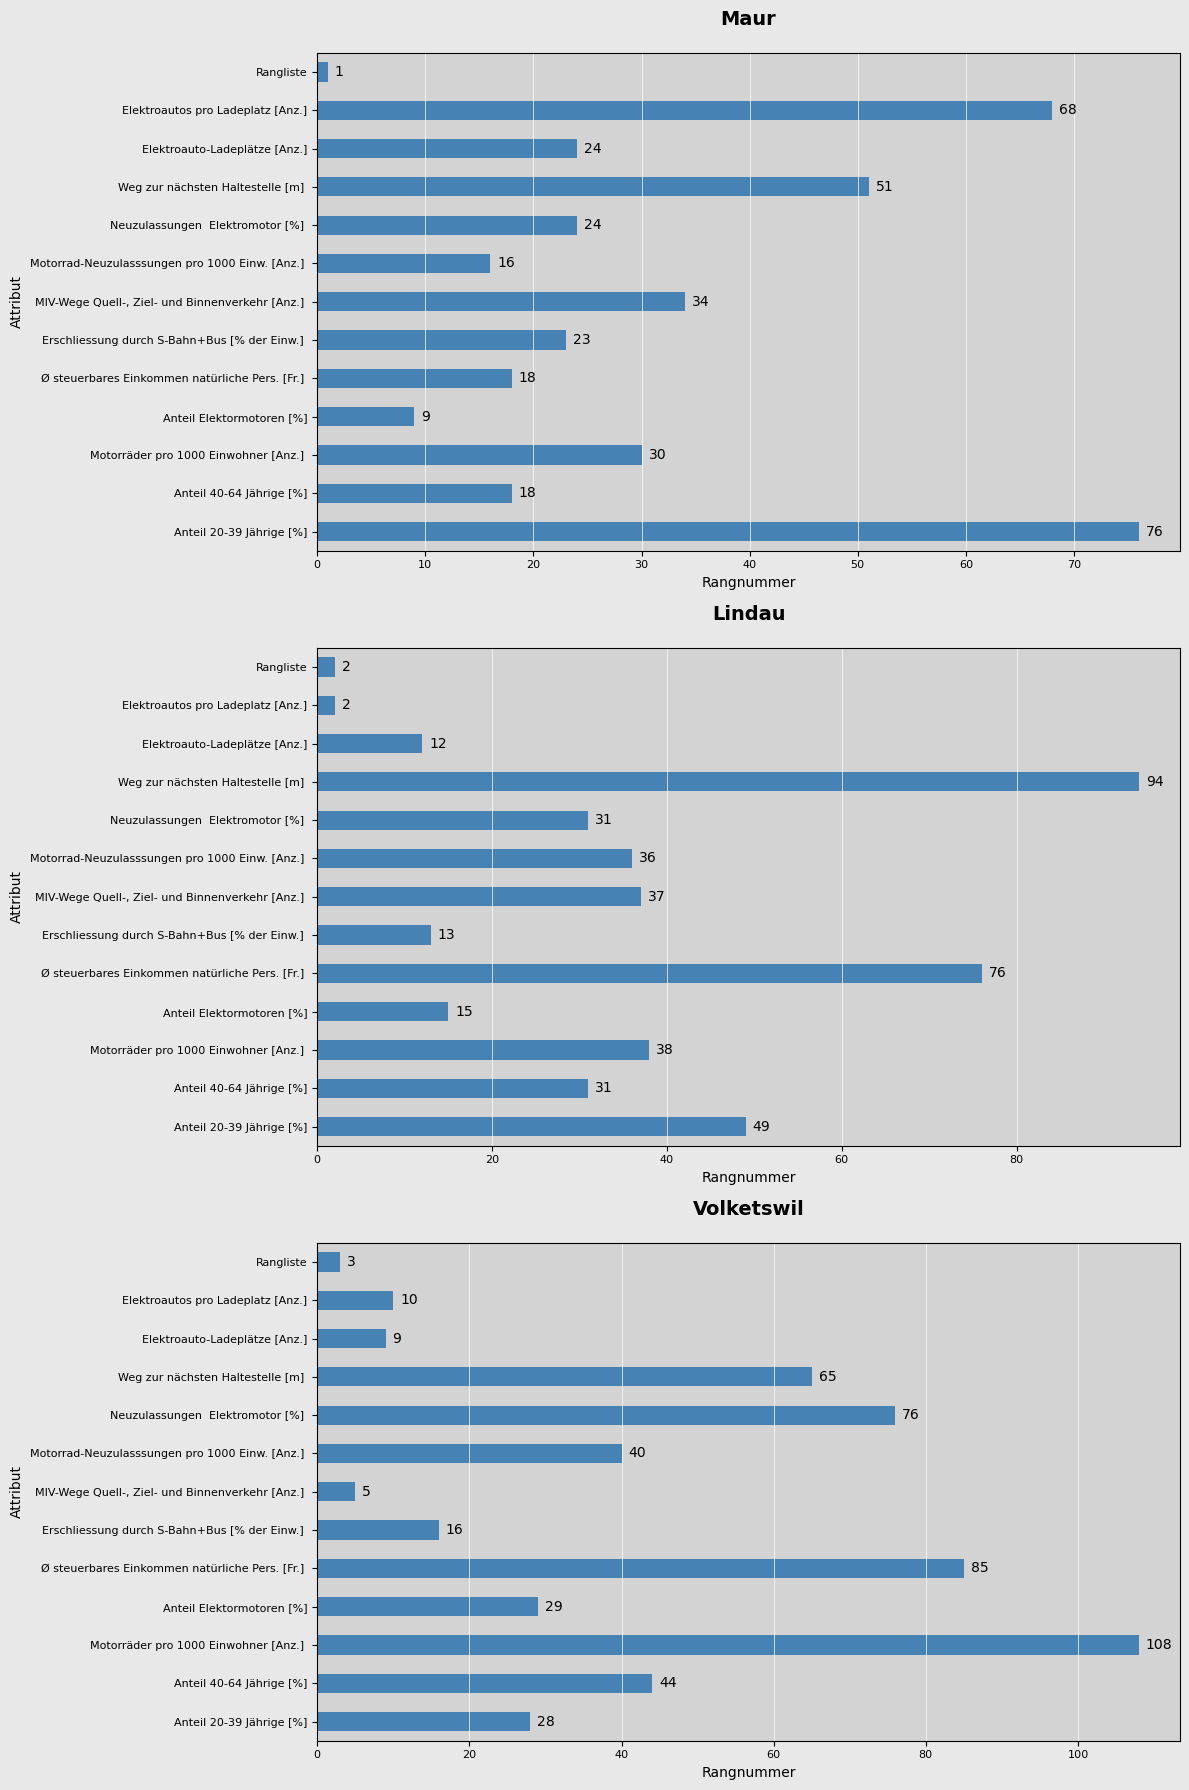

In [27]:
# Hintergrundfarbe setzen
fig, axs = plt.subplots(3, 1, figsize=(12, 18))
fig.patch.set_facecolor('#E8E8E8')

# Definiere eine Funktion zum Plotten des Histogramms
def plot_histogram(ax, df, title):
    ax.set_facecolor('#D3D3D3')
    df.plot(kind='barh', x= 'Attribute', y='Rang', ax=ax, color='steelblue', legend=False)
    
    ax.set_xlabel('Rangnummer')
    ax.set_ylabel('Attribut')
    # Y-Achsen-Ticks kleiner machen
    ax.tick_params(axis='y', labelsize=8)
        # Y-Achsen-Ticks kleiner machen
    ax.tick_params(axis='x', labelsize=8)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Gitternetzlinien hinzufügen
    ax.grid(True, axis='x', which='both', linestyle='-', linewidth=0.5, color='white')
    
    # Wertelabels annotieren
    for index, value in enumerate(df['Rang']):
        label = format(int(value), ',')  # Formatieren des Werts mit Kommas
        # Text am Ende des Balkens platzieren (Anpassung der Position für bessere Lesbarkeit)
        ax.annotate(label, xy=(value, index), xytext=(5, 0),
                    textcoords='offset points', ha='left', va='center', color='black')

# Erstelle die drei Subplots
plot_histogram(axs[0], df_gesamt_ranking_top3_1, df_gesamt_ranking[df_gesamt_ranking["Rangliste"] == 1]["municipality"].iloc[0])
plot_histogram(axs[1], df_gesamt_ranking_top3_2, df_gesamt_ranking[df_gesamt_ranking["Rangliste"] == 2]["municipality"].iloc[0])
plot_histogram(axs[2], df_gesamt_ranking_top3_3, df_gesamt_ranking[df_gesamt_ranking["Rangliste"] == 3]["municipality"].iloc[0])

# Layout anpassen
plt.tight_layout()

# Plot als .jpg speichern
plt.savefig("./pictures/Histogramm_Top3_Rangnummern.jpg", format='jpg')

# Diagramm anzeigen
plt.show()

### Durchschnittlicher Punkteunterschied zwischen Rängen

In [28]:
# Erstelle ein neues DataFrame mit den Spalten, die '_rank' enthalten
columns_points = [col for col in df_ranking.columns if '_rank' not in col]
df_points = df_ranking[columns_points].copy() 

In [29]:
df_points

,Anteil 20-39 Jährige [%],Anteil 40-64 Jährige [%],Motorräder pro 1000 Einwohner [Anz.],Anteil Elektormotoren [%],Ø steuerbares Einkommen natürliche Pers. [Fr.],Erschliessung durch S-Bahn+Bus [% der Einw.],"MIV-Wege Quell-, Ziel- und Binnenverkehr [Anz.]",Motorrad-Neuzulasssungen pro 1000 Einw. [Anz.],Neuzulassungen Elektromotor [%],Weg zur nächsten Haltestelle [m],Elektroauto-Ladeplätze [Anz.],Elektroautos pro Ladeplatz [Anz.],Ranking Gesamt [Punkte],bfs_nr,Rangliste
0,0.33,5.39,3.87,2.15,4.20,9.8,8.2,0.08,15.00,5.0,0.1,0.1,54.22,1,70.0
1,2.37,0.56,0.39,0.85,0.93,6.4,28.8,0.24,8.10,8.1,1.7,8.2,66.64,2,7.0
2,1.11,2.87,2.13,1.45,3.57,6.2,14.4,1.12,5.70,4.1,0.4,2.6,45.65,3,121.0
3,0.39,4.27,2.85,1.50,3.12,9.8,10.4,1.16,9.90,6.6,0.5,4.8,55.29,4,60.0
4,1.44,3.57,1.74,1.45,3.93,1.0,12.2,1.56,9.60,7.8,0.1,0.1,44.49,5,124.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1.74,1.68,1.59,0.70,1.20,6.0,17.4,1.96,5.70,10.0,0.1,0.1,48.17,294,106.0
156,1.71,2.31,0.96,1.45,3.81,7.1,29.4,0.88,9.00,1.6,0.6,0.7,59.52,295,32.0
157,2.31,0.77,0.27,0.60,0.75,2.4,28.6,0.52,5.70,3.3,1.5,6.2,52.92,296,80.0
158,1.47,3.22,3.54,0.35,0.54,5.4,19.2,1.80,2.55,9.5,0.6,7.4,55.57,297,59.0


In [30]:
# Initialisiere das DataFrame average als leeres DataFrame mit den gleichen Spaltennamen
average = pd.DataFrame(columns=df_points.columns[:len(df_points.columns)-3])

# Über alle Spalten iterieren.
for i in range(0, len(df_points.columns)-3):
    # Spalte extrahieren und sortieren
    df_temp = df_points[df_points.columns[i]].sort_values().reset_index(drop=True)
    v_differenz = []

    # Über alle Zeilen iterieren
    for j in range(0, len(df_temp)-1):
        # Differenz berechnen
        diff = df_temp[j+1] - df_temp[j]
        if diff >= 0:
            v_differenz.append(diff)

    # Durchschnitt der Serie berechnen
    average.loc[0, df_points.columns[i]] = statistics.mean(v_differenz)
    average.loc[1, df_points.columns[i]] = df_temp[len(df_temp)-1] - df_temp[0]

In [31]:
# Transponiere DataFrmae
punkteunterschied = average.transpose()
# Index zu einer Spalte machen und die Spalte 'index' umbenennen
punkteunterschied.reset_index(inplace=True)
# Benenne Spalte um.
punkteunterschied.rename(columns={"index" : "Attribute", 0: "Durchschnittlicher Punkteunterschied", 1: "maximaler Punkteunterschied"}, inplace=True)

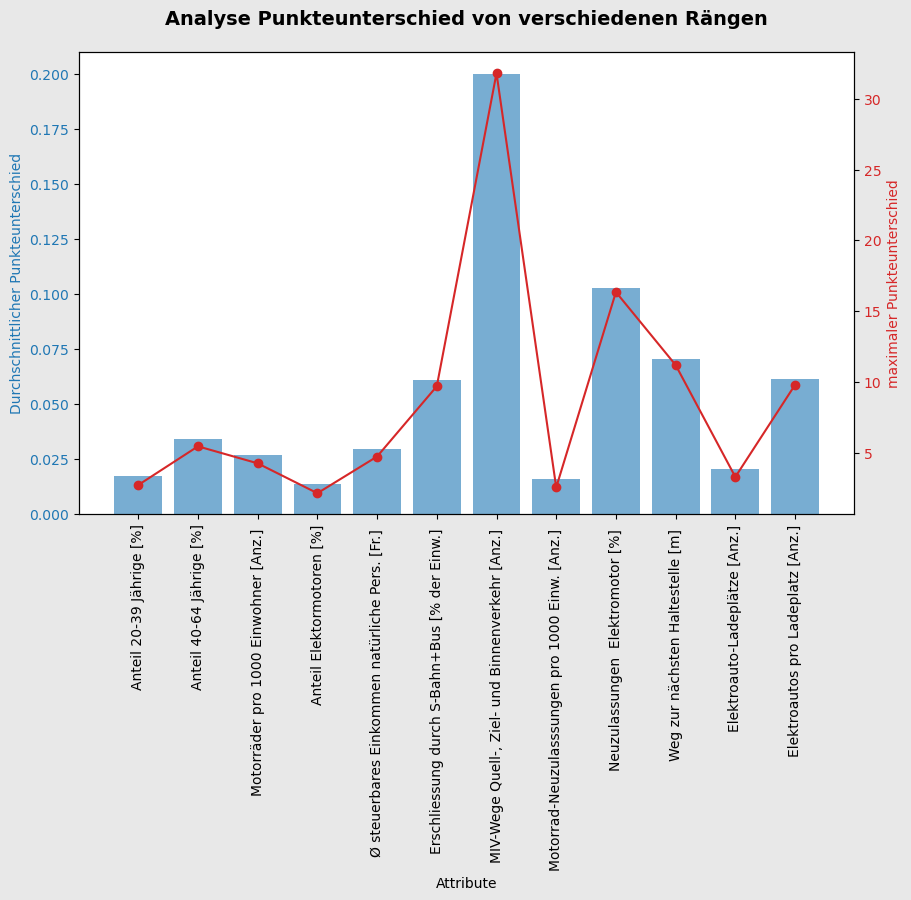

In [34]:
# Plot für die erste y-Achse
fig, ax1 = plt.subplots(figsize=(10, 6))
# Hintergrundfarbe setzen
fig.patch.set_facecolor('#E8E8E8')

ax1.bar(punkteunterschied["Attribute"], punkteunterschied['Durchschnittlicher Punkteunterschied'], color='tab:blue', alpha=0.6)
ax1.set_xlabel('Attribute')
ax1.set_ylabel('Durchschnittlicher Punkteunterschied', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')


# Zweite y-Achse hinzufügen
ax2 = ax1.twinx()
ax2.plot(punkteunterschied["Attribute"], punkteunterschied['maximaler Punkteunterschied'], color='tab:red', marker='o')
ax2.set_ylabel('maximaler Punkteunterschied', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.tick_params(axis='x', rotation=90)  # X-Achsenbeschriftungen vertikal stellen

# Titel hinzufügen
plt.title('Analyse Punkteunterschied von verschiedenen Rängen', fontsize=14, fontweight='bold', pad=20)

# Plot als .jpg speichern
plt.savefig("./pictures/Analyse_Punkteunterschied.jpg", format='jpg', bbox_inches='tight', pad_inches=0.1)

# Plot anzeigen
plt.show()